# How do the long-term returns of leveraged ETFs diverge from their underlying index?

## Python Imports

In [1]:
# Standard Library
import datetime
import io
import os
import random
import sys
import warnings

from datetime import datetime, timedelta
from pathlib import Path

# Data Handling
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter, FuncFormatter, MultipleLocator

# Data Sources
import yfinance as yf
import pandas_datareader.data as web

# Statistical Analysis
import statsmodels.api as sm

# Machine Learning
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Suppress warnings
warnings.filterwarnings("ignore")

## Add Directories To Path

In [2]:
# Add the source subdirectory to the system path to allow import config from settings.py
current_directory = Path(os.getcwd())
website_base_directory = current_directory.parent.parent.parent
src_directory = website_base_directory / "src"
sys.path.append(str(src_directory)) if str(src_directory) not in sys.path else None

# Import settings.py
from settings import config

# Add configured directories from config to path
SOURCE_DIR = config("SOURCE_DIR")
sys.path.append(str(Path(SOURCE_DIR))) if str(Path(SOURCE_DIR)) not in sys.path else None

# Add other configured directories
BASE_DIR = config("BASE_DIR")
CONTENT_DIR = config("CONTENT_DIR")
POSTS_DIR = config("POSTS_DIR")
PAGES_DIR = config("PAGES_DIR")
PUBLIC_DIR = config("PUBLIC_DIR")
SOURCE_DIR = config("SOURCE_DIR")
DATA_DIR = config("DATA_DIR")
DATA_MANUAL_DIR = config("DATA_MANUAL_DIR")

# Print system path
for i, path in enumerate(sys.path):
    print(f"{i}: {path}")

0: /usr/lib/python313.zip
1: /usr/lib/python3.13
2: /usr/lib/python3.13/lib-dynload
3: 
4: /home/jared/python-virtual-envs/general-venv-p313/lib/python3.13/site-packages
5: /home/jared/python-virtual-envs/general-venv-p313/lib/python3.13/site-packages/setuptools/_vendor
6: /home/jared/Cloud_Storage/Dropbox/Websites/jaredszajkowski.github.io_congo/src


## Track Index Dependencies

In [3]:
# Create file to track markdown dependencies
dep_file = Path("index_dep.txt")
dep_file.write_text("")

0

## Python Functions

In [4]:
from build_index import build_index
from df_info import df_info
from df_info_markdown import df_info_markdown
from export_track_md_deps import export_track_md_deps
from load_data import load_data
from pandas_set_decimal_places import pandas_set_decimal_places
from plot_timeseries import plot_timeseries
from summary_stats import summary_stats
from yf_pull_data import yf_pull_data

In [5]:
# Set decimal places
pandas_set_decimal_places(2)

## Data Overview

### Acquire & Plot Data (QQQ)

In [6]:
yf_pull_data(
    base_directory=DATA_DIR,
    ticker="QQQ",
    source="Yahoo_Finance", 
    asset_class="Exchange_Traded_Funds", 
    excel_export=True,
    pickle_export=True,
    output_confirmation=True,
)

qqq = load_data(
    base_directory=DATA_DIR,
    ticker="QQQ",
    source="Yahoo_Finance", 
    asset_class="Exchange_Traded_Funds",
    timeframe="Daily",
    file_format="pickle",
)

# Rename columns to "QQQ_Close", etc.
qqq = qqq.rename(columns={
    "Close": "QQQ_Close", 
    "High": "QQQ_High", 
    "Low": "QQQ_Low", 
    "Open": "QQQ_Open", 
    "Volume": "QQQ_Volume"
})

[*********************100%***********************]  1 of 1 completed

The first and last date of data for QQQ is: 


,Close,High,Low,Open,Volume
Date,,,,,
1999-03-10,43.13,43.21,42.47,43.18,5232000


,Close,High,Low,Open,Volume
Date,,,,,
2026-01-22,620.76,622.46,617.78,622.35,42254800


Yahoo Finance data complete for QQQ
--------------------


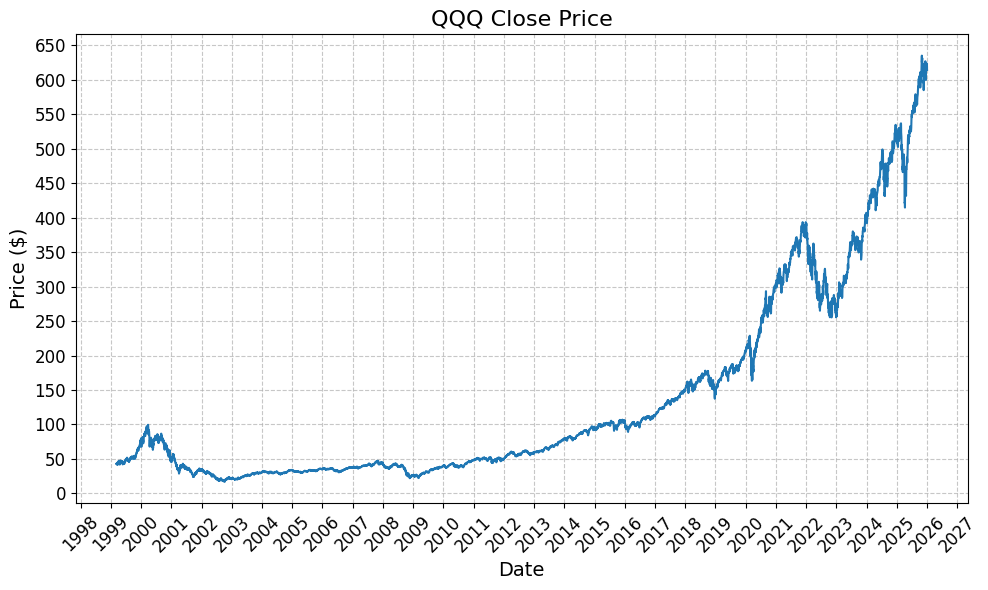

In [7]:
plot_timeseries(
    price_df=qqq,
    plot_start_date="1999-03-10",
    plot_end_date="2025-12-31",
    plot_columns=["QQQ_Close"],
    title="QQQ Close Price",
    x_label="Date",
    x_format="Year",
    x_tick_rotation=45,
    y_label="Price ($)",
    y_format="Decimal",
    y_format_decimal_places=0,
    y_tick_spacing=50,
    grid=True,
    legend=False,
    export_plot=True,
    plot_file_name="01_QQQ_Price",
)

In [8]:
# Copy this <!-- INSERT_01_QQQ_Price_HERE --> to index_temp.md
export_track_md_deps(
    dep_file=dep_file, 
    md_filename="01_QQQ_Price.md", 
    content=df_info_markdown(df=qqq, decimal_places=2),
    output_type="text",
)

✅ Exported and tracked: 01_QQQ_Price.md


### Acquire & Plot Data (TQQQ)

In [9]:
yf_pull_data(
    base_directory=DATA_DIR,
    ticker="TQQQ",
    source="Yahoo_Finance", 
    asset_class="Exchange_Traded_Funds", 
    excel_export=True,
    pickle_export=True,
    output_confirmation=True,
)

tqqq = load_data(
    base_directory=DATA_DIR,
    ticker="TQQQ",
    source="Yahoo_Finance", 
    asset_class="Exchange_Traded_Funds",
    timeframe="Daily",
    file_format="pickle",
)

# Rename columns to "TQQQ_Close", etc.
tqqq = tqqq.rename(columns={
    "Close": "TQQQ_Close", 
    "High": "TQQQ_High", 
    "Low": "TQQQ_Low", 
    "Open": "TQQQ_Open", 
    "Volume": "TQQQ_Volume"
})


[*********************100%***********************]  1 of 1 completed

The first and last date of data for TQQQ is: 


,Close,High,Low,Open,Volume
Date,,,,,
2010-02-11,0.21,0.21,0.19,0.19,6912000


,Close,High,Low,Open,Volume
Date,,,,,
2026-01-22,53.90,54.33,53.15,54.32,90992300


Yahoo Finance data complete for TQQQ
--------------------


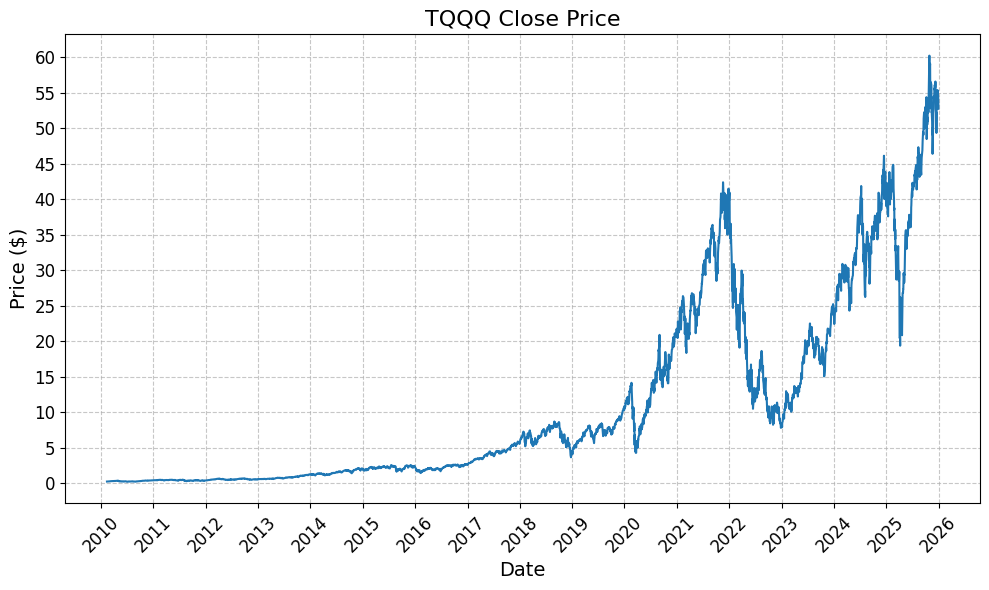

In [10]:
plot_timeseries(
    price_df=tqqq,
    plot_start_date="2010-02-11",
    plot_end_date="2025-12-31",
    plot_columns=["TQQQ_Close"],
    title="TQQQ Close Price",
    x_label="Date",
    x_format="Year",
    x_tick_rotation=45,
    y_label="Price ($)",
    y_format="Decimal",
    y_format_decimal_places=0,
    y_tick_spacing=5,
    grid=True,
    legend=False,
    export_plot=True,
    plot_file_name="02_TQQQ_Price",
)

In [11]:
# Copy this <!-- INSERT_02_TQQQ_Price_HERE --> to index_temp.md
export_track_md_deps(
    dep_file=dep_file, 
    md_filename="02_TQQQ_Price.md", 
    content=df_info_markdown(df=qqq, decimal_places=2),
    output_type="text",
)

✅ Exported and tracked: 02_TQQQ_Price.md


### Calculate Cumulative Returns & Drawdowns (QQQ & TQQQ)

In [12]:
etfs = ["QQQ", "TQQQ"]

# Merge dataframes and drop rows with missing values
qqq_tqqq_aligned = tqqq.merge(qqq, left_index=True, right_index=True, how='left')
qqq_tqqq_aligned = qqq_tqqq_aligned.dropna()

# Calculate cumulative returns
for etf in etfs:
    qqq_tqqq_aligned[f"{etf}_Return"] = qqq_tqqq_aligned[f"{etf}_Close"].pct_change()
    qqq_tqqq_aligned[f"{etf}_Cumulative_Return"] = (1 + qqq_tqqq_aligned[f"{etf}_Return"]).cumprod() - 1
    qqq_tqqq_aligned[f"{etf}_Cumulative_Return_Plus_One"] = 1 + qqq_tqqq_aligned[f"{etf}_Cumulative_Return"]
    qqq_tqqq_aligned[f"{etf}_Rolling_Max"] = qqq_tqqq_aligned[f"{etf}_Cumulative_Return_Plus_One"].cummax()
    qqq_tqqq_aligned[f"{etf}_Drawdown"] = qqq_tqqq_aligned[f"{etf}_Cumulative_Return_Plus_One"] / qqq_tqqq_aligned[f"{etf}_Rolling_Max"] - 1
    qqq_tqqq_aligned.drop(columns=[f"{etf}_Cumulative_Return_Plus_One", f"{etf}_Rolling_Max"], inplace=True)

In [13]:
qqq_tqqq_aligned

,TQQQ_Close,TQQQ_High,TQQQ_Low,TQQQ_Open,TQQQ_Volume,QQQ_Close,QQQ_High,QQQ_Low,QQQ_Open,QQQ_Volume,QQQ_Return,QQQ_Cumulative_Return,QQQ_Drawdown,TQQQ_Return,TQQQ_Cumulative_Return,TQQQ_Drawdown
Date,,,,,,,,,,,,,,,,
2010-02-11,0.21,0.21,0.19,0.19,6912000,37.95,38.06,37.16,37.40,93050800,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-12,0.21,0.21,0.20,0.20,17203200,38.03,38.13,37.51,37.61,93938500,0.00,0.00,0.00,0.00,0.00,0.00
2010-02-16,0.22,0.22,0.21,0.21,19238400,38.52,38.54,38.11,38.31,83861400,0.01,0.01,0.00,0.04,0.04,0.00
2010-02-17,0.22,0.22,0.21,0.22,38361600,38.73,38.73,38.46,38.69,82691700,0.01,0.02,0.00,0.02,0.06,0.00
2010-02-18,0.22,0.22,0.22,0.22,77721600,38.98,39.05,38.63,38.71,65752600,0.01,0.03,0.00,0.02,0.08,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-15,54.38,55.83,54.13,55.65,90483000,621.78,630.00,620.75,626.60,53934900,0.00,15.38,-0.02,0.01,262.47,-0.10
2026-01-16,54.14,55.46,53.58,55.32,75855900,621.26,626.08,618.88,625.50,61058100,-0.00,15.37,-0.02,-0.00,261.31,-0.10
2026-01-20,50.73,52.56,50.48,51.39,129209100,608.06,615.06,607.05,610.53,81988900,-0.02,15.02,-0.04,-0.06,244.79,-0.16


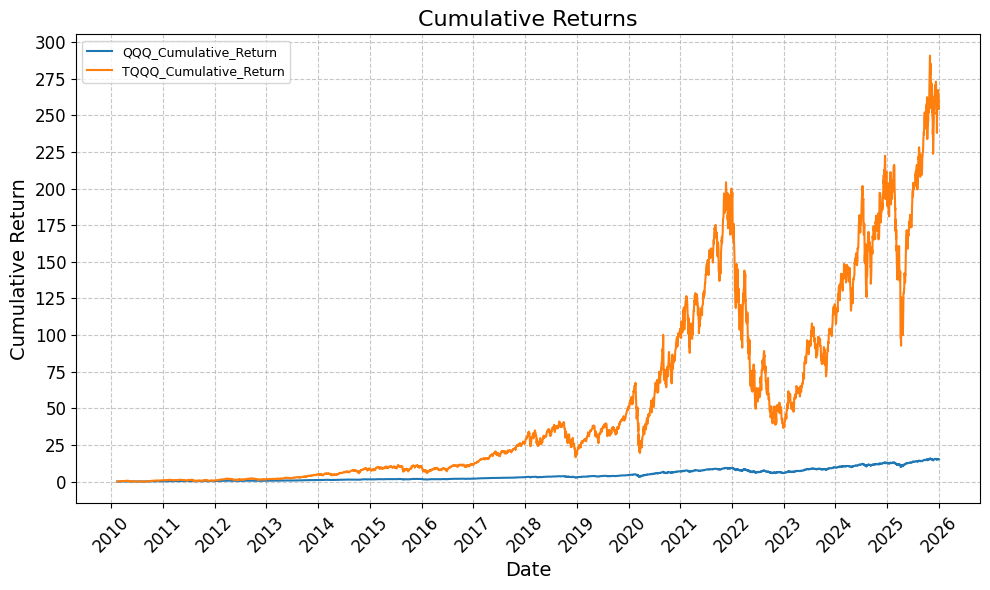

In [14]:
plot_timeseries(
    price_df=qqq_tqqq_aligned,
    plot_start_date="2010-02-11",
    plot_end_date="2025-12-31",
    plot_columns=["QQQ_Cumulative_Return", "TQQQ_Cumulative_Return"],
    title="Cumulative Returns",
    x_label="Date",
    x_format="Year",
    x_tick_rotation=45,
    y_label="Cumulative Return",
    y_format="Decimal",
    y_format_decimal_places=0,
    y_tick_spacing=25,
    grid=True,
    legend=True,
    export_plot=True,
    plot_file_name="03_Cumulative_Returns",
)

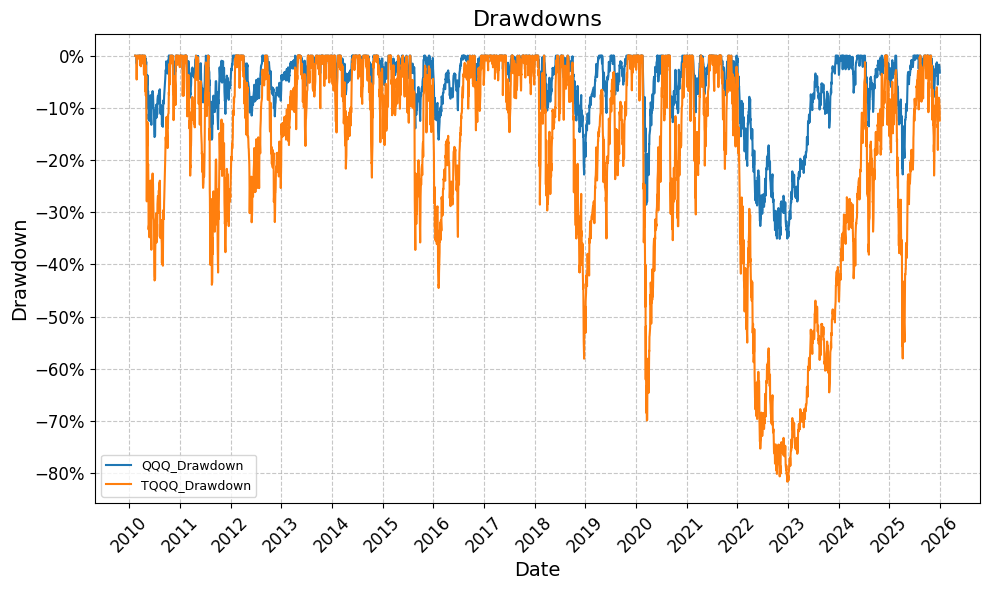

In [15]:
plot_timeseries(
    price_df=qqq_tqqq_aligned,
    plot_start_date="2010-02-11",
    plot_end_date="2025-12-31",
    plot_columns=["QQQ_Drawdown", "TQQQ_Drawdown"],
    title="Drawdowns",
    x_label="Date",
    x_format="Year",
    x_tick_rotation=45,
    y_label="Drawdown",
    y_format="Percentage",
    y_format_decimal_places=0,
    y_tick_spacing=0.10,
    grid=True,
    legend=True,
    export_plot=True,
    plot_file_name="03_Drawdowns",
)

In [16]:
# port_sum_stats = summary_stats(
#     fund_list=["Portfolio", "SPY", "TLT"],
#     df=portfolio_monthly[["Portfolio_Monthly_Return"]],
#     period="Monthly",
#     use_calendar_days=False,
#     excel_export=False,
#     pickle_export=False,
#     output_confirmation=False,
# )

# spy_sum_stats = summary_stats(
#     fund_list=["Portfolio", "SPY", "TLT"],
#     df=portfolio_monthly[["SPY_Monthly_Return"]],
#     period="Monthly",
#     use_calendar_days=False,
#     excel_export=False,
#     pickle_export=False,
#     output_confirmation=False,
# )

# tlt_sum_stats = summary_stats(
#     fund_list=["Portfolio", "SPY", "TLT"],
#     df=portfolio_monthly[["TLT_Monthly_Return"]],
#     period="Monthly",
#     use_calendar_days=False,
#     excel_export=False,
#     pickle_export=False,
#     output_confirmation=False,
# )

# sum_stats = port_sum_stats.combine_first(spy_sum_stats).combine_first(tlt_sum_stats)

In [17]:
# # Copy this <!-- INSERT_05_Portfolio_Stats_DF_HERE --> to index_temp.md
# export_track_md_deps(dep_file=dep_file, md_filename="05_Portfolio_Stats_DF.md", content=sum_stats.to_markdown(floatfmt=".3f"))